# FCN3 vs HRES: 10 m Wind Speed Comparison – 2016 (+12 h Lead)

Compares **FCN3** (nearest grid-cell extracted from full-grid multistep output, +12 h lead) and
**HRES** (ECMWF WeatherBench2 0.25°, +12 h lead) against hourly station observations.

**Aligned period:** 2016-01-01 → 2016-05-12

| Station ID | Name | Lat | Lon |
|---|---|---|---|
| SN88690 | Hekkingen Fyr | 69.60 N | 17.83 E |
| SN90490 | Tromsø-Langnes | 69.68 N | 18.91 E |
| SN90760 | Fakken | 70.10 N | 20.11 E |



In [71]:
import warnings
warnings.filterwarnings('ignore')

# nest_asyncio lets zarr v3 async code run inside Jupyter's existing event loop
import nest_asyncio
nest_asyncio.apply()

import zarr
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

print('zarr  :', zarr.__version__)
print('numpy :', np.__version__)
print('pandas:', pd.__version__)
print('xarray:', xr.__version__)


zarr  : 3.1.6
numpy : 2.4.4
pandas: 3.0.3
xarray: 2026.4.0


In [72]:
# ── Paths ──────────────────────────────────────────────────────────────────
FCN3_DIR  = Path('/cluster/work/projects/nn8106k/siyan/WF-experiments/outputs/fcn3_station_weekly_multistep_2016')
HRES_PATH = Path('/cluster/work/projects/nn8106k/siyan/weatherbench2_forecasts/hres/0p25/2016-2022-0012-1440x721.zarr')
OBS_DIR   = Path('/cluster/home/siyan/github/WF-experiments/experiments/outputs/wind_obs')

FIG_DIR = Path('/cluster/home/siyan/github/WF-experiments/experiments/notebooks/figures/fcn3_hres_2016')
FIG_DIR.mkdir(parents=True, exist_ok=True)
print(f'Figures → {FIG_DIR}')

# ── Experiment settings ─────────────────────────────────────────────────────
LEAD_H       = 12
PERIOD_START = '2016-01-01'
PERIOD_END   = '2016-05-12'

# ── Station metadata ────────────────────────────────────────────────────────
STATIONS = {
    'SN88690': {'name': 'Hekkingen Fyr',  'lat': 69.6005,  'lon': 17.8317},
    'SN90490': {'name': 'Tromsø-Langnes', 'lat': 69.6767,  'lon': 18.9133},
    'SN90760': {'name': 'Fakken',          'lat': 70.10426, 'lon': 20.11451},
}

OBS_STATION_NAMES = {
    'SN88690': 'SN88690_Hekkingen_Fyr',
    'SN90490': 'SN90490_Tromsoe_Langnes',
    'SN90760': 'SN90760_Fakken',
}

CLR = {
    'FCN3': '#E74C3C',
    'HRES': '#E67E22',
    'Obs':  '#27AE60',
}


Figures → /cluster/home/siyan/github/WF-experiments/experiments/notebooks/figures/fcn3_hres_2016


## 1  Load Observations

In [73]:
def load_observations(obs_dir: Path, obs_station_names: dict,
                      start: str, end: str) -> pd.DataFrame:
    """Load hourly per-year obs CSVs and compute 12-hour trailing mean per station.

    obs_station_names: {station_id: file_base_name}
      e.g. 'SN88690' -> 'SN88690_Hekkingen_Fyr'
    Files are expected as <base_name>_<year>.csv.
    """
    start_yr = pd.Timestamp(start).year
    end_yr   = pd.Timestamp(end).year

    dfs = []
    for sid, base in obs_station_names.items():
        parts = []
        for yr in range(start_yr, end_yr + 1):
            f = obs_dir / f'{base}_{yr}.csv'
            if not f.exists():
                print(f'  Warning: {f.name} not found, skipping.')
                continue
            df = pd.read_csv(f)
            df['valid_time'] = pd.to_datetime(df['time'], utc=True).dt.tz_localize(None)
            df['station'] = sid
            df = df.rename(columns={'wind_speed': 'obs_wind'})
            parts.append(df[['station', 'valid_time', 'obs_wind']].dropna(subset=['obs_wind']))

        if not parts:
            continue

        sdf = pd.concat(parts, ignore_index=True).sort_values('valid_time')
        # 12-hour trailing mean; require at least 6 obs in window
        sdf['obs_wind'] = (
            sdf.set_index('valid_time')['obs_wind']
            .rolling('12h', min_periods=6)
            .mean()
            .values
        )
        dfs.append(sdf.dropna(subset=['obs_wind']))

    obs = pd.concat(dfs, ignore_index=True)
    obs = obs[(obs['valid_time'] >= start) & (obs['valid_time'] <= end)]
    return obs


obs_df = load_observations(OBS_DIR, OBS_STATION_NAMES, PERIOD_START, PERIOD_END)
print(f'Observations (12h trailing mean): {len(obs_df):,} rows')
print(f'  Time range : {obs_df["valid_time"].min()} → {obs_df["valid_time"].max()}')
obs_df.head(3)


Observations (12h trailing mean): 9,417 rows
  Time range : 2016-01-01 05:00:00 → 2016-05-12 00:00:00


,station,valid_time,obs_wind
0,SN88690,2016-01-01 05:00:00,13.550000
1,SN88690,2016-01-01 06:00:00,13.228571
2,SN88690,2016-01-01 07:00:00,13.037500


## 2  Load FCN3 (Multistep Full Grid, +12 h Lead)

In [74]:
def _nearest_idx(arr: np.ndarray, target: float) -> int:
    return int(np.argmin(np.abs(arr - target)))


def load_fcn3_multistep_weekly(zarr_path: Path, stations: dict, lead_h: float) -> pd.DataFrame:
    """Extract station wind speed from one FCN3 multistep weekly zarr (full global grid).
    Uses xr.open_zarr to avoid zarr-v3 async conflicts inside Jupyter.
    """
    ds = xr.open_zarr(str(zarr_path), consolidated=True)

    lats = ds['lat'].values
    lons = ds['lon'].values

    # lead_time may be int hours or timedelta64 depending on how the file was written
    lt_raw = ds['lead_time'].values
    if np.issubdtype(lt_raw.dtype, np.timedelta64):
        lt_hours = (lt_raw / np.timedelta64(1, 'h')).astype(float)
    else:
        lt_hours = lt_raw.astype(float)
    lt_idx  = int(np.argmin(np.abs(lt_hours - lead_h)))
    lt_used = float(lt_hours[lt_idx])

    init_times = pd.DatetimeIndex(ds['time'].values)

    # u10m / v10m: shape (n_init, n_lead, n_lat, n_lon)
    ws_all = np.sqrt(ds['u10m'].values ** 2 + ds['v10m'].values ** 2)

    records = []
    for sid, info in stations.items():
        lat_i = _nearest_idx(lats, info['lat'])
        lon_i = _nearest_idx(lons, info['lon'])
        for t_i, init_t in enumerate(init_times):
            wind = float(ws_all[t_i, lt_idx, lat_i, lon_i])
            if np.isnan(wind):
                continue
            records.append({
                'station':     sid,
                'init_time':   init_t,
                'lead_time_h': lt_used,
                'valid_time':  init_t + pd.Timedelta(hours=lt_used),
                'fcn3_wind':   wind,
            })
    return pd.DataFrame(records)


import json as _json

def _is_empty_zarr(path: Path) -> bool:
    """Return True if the zarr group has no arrays (failed/incomplete run)."""
    try:
        meta = _json.load(open(path / 'zarr.json'))
        n = len(meta.get('consolidated_metadata', {}).get('metadata', {}))
        return n == 0
    except Exception:
        return True


fcn3_files = sorted(FCN3_DIR.glob('fcn3_station_wind_multistep_*.zarr'))
print(f'FCN3 files found: {len(fcn3_files)}')

fcn3_parts = []
skipped = 0
for f in fcn3_files:
    if _is_empty_zarr(f):
        print(f'  {f.name} ... SKIPPED (empty/failed run)')
        skipped += 1
        continue
    print(f'  {f.name} ...', end=' ', flush=True)
    df = load_fcn3_multistep_weekly(f, STATIONS, lead_h=LEAD_H)
    fcn3_parts.append(df)
    print(f'{len(df)} records')

print(f'\nSkipped {skipped} empty files.')
fcn3_df = (
    pd.concat(fcn3_parts, ignore_index=True)
    .drop_duplicates(subset=['station', 'valid_time'])
    .sort_values(['station', 'valid_time'])
    .reset_index(drop=True)
)
print(f'FCN3 total  : {len(fcn3_df):,} records')
print(f'Valid range : {fcn3_df["valid_time"].min()} → {fcn3_df["valid_time"].max()}')
fcn3_df.head(3)


FCN3 files found: 19
  fcn3_station_wind_multistep_20160101_20160107.zarr ... 21 records
  fcn3_station_wind_multistep_20160108_20160114.zarr ... 21 records
  fcn3_station_wind_multistep_20160115_20160121.zarr ... 21 records
  fcn3_station_wind_multistep_20160122_20160128.zarr ... SKIPPED (empty/failed run)
  fcn3_station_wind_multistep_20160129_20160204.zarr ... 21 records
  fcn3_station_wind_multistep_20160205_20160211.zarr ... 21 records
  fcn3_station_wind_multistep_20160212_20160218.zarr ... 21 records
  fcn3_station_wind_multistep_20160219_20160225.zarr ... 21 records
  fcn3_station_wind_multistep_20160226_20160303.zarr ... SKIPPED (empty/failed run)
  fcn3_station_wind_multistep_20160304_20160310.zarr ... SKIPPED (empty/failed run)
  fcn3_station_wind_multistep_20160311_20160317.zarr ... 21 records
  fcn3_station_wind_multistep_20160318_20160324.zarr ... 21 records
  fcn3_station_wind_multistep_20160325_20160331.zarr ... 21 records
  fcn3_station_wind_multistep_20160401_20160407

,station,init_time,lead_time_h,valid_time,fcn3_wind
0,SN88690,2016-01-01,12.0,2016-01-01 12:00:00,5.783884
1,SN88690,2016-01-02,12.0,2016-01-02 12:00:00,5.549573
2,SN88690,2016-01-03,12.0,2016-01-03 12:00:00,2.038846


## 3  Load HRES (WeatherBench2)

In [75]:
hres_ds = xr.open_zarr(HRES_PATH, consolidated=False)
print('HRES time  :', pd.Timestamp(hres_ds['time'].values[0]), '→',
      pd.Timestamp(hres_ds['time'].values[-1]))
print('HRES leads (h, first 6):', hres_ds['prediction_timedelta'].values[:6])


def load_wb2_at_stations(ds: xr.Dataset, wind_var: str, lat_coord: str,
                          lon_coord: str, lead_coord: str,
                          stations: dict, lead_h: int,
                          start: str, end: str, col_name: str) -> pd.DataFrame:
    """Extract nearest-grid-point 10 m wind at given lead from a WeatherBench2 dataset."""
    da = ds[wind_var].sel({lead_coord: lead_h})
    da = da.sel(time=slice(start, end))
    init_times = pd.DatetimeIndex(da['time'].values)
    records = []
    for sid, info in stations.items():
        target_lon = info['lon'] % 360
        ws_vals = da.sel(
            {lat_coord: info['lat'], lon_coord: target_lon}, method='nearest'
        ).values
        for t_i, init_t in enumerate(init_times):
            val = float(ws_vals[t_i])
            if np.isnan(val):
                continue
            records.append({
                'station':     sid,
                'init_time':   init_t,
                'lead_time_h': float(lead_h),
                'valid_time':  init_t + pd.Timedelta(hours=float(lead_h)),
                col_name:      val,
            })
    return pd.DataFrame(records)


hres_df = load_wb2_at_stations(
    hres_ds, wind_var='10m_wind_speed',
    lat_coord='latitude', lon_coord='longitude', lead_coord='prediction_timedelta',
    stations=STATIONS, lead_h=LEAD_H, start=PERIOD_START, end=PERIOD_END,
    col_name='hres_wind',
)
hres_df = (
    hres_df
    .drop_duplicates(subset=['station', 'valid_time'])
    .sort_values(['station', 'valid_time'])
    .reset_index(drop=True)
)
print(f'HRES records: {len(hres_df):,}')
print(f'Valid range : {hres_df["valid_time"].min()} → {hres_df["valid_time"].max()}')
hres_df.head(3)


HRES time  : 2016-01-01 00:00:00 → 2023-01-10 12:00:00
HRES leads (h, first 6): [ 0  6 12 18 24 30]
HRES records: 798
Valid range : 2016-01-01 12:00:00 → 2016-05-13 00:00:00


,station,init_time,lead_time_h,valid_time,hres_wind
0,SN88690,2016-01-01 00:00:00,12.0,2016-01-01 12:00:00,5.095023
1,SN88690,2016-01-01 12:00:00,12.0,2016-01-02 00:00:00,4.264834
2,SN88690,2016-01-02 00:00:00,12.0,2016-01-02 12:00:00,3.492679


## 4  Align Datasets

In [76]:
for _df in [fcn3_df, hres_df, obs_df]:
    _df['valid_time'] = _df['valid_time'].astype('datetime64[us]')


merged = pd.merge(
    fcn3_df[['station', 'valid_time', 'fcn3_wind']],
    hres_df[['station', 'valid_time', 'hres_wind']],
    on=['station', 'valid_time'], how='inner',
)
print(f'FCN3 ∩ HRES       : {len(merged):,}')

merged = pd.merge(
    merged,
    obs_df[['station', 'valid_time', 'obs_wind']],
    on=['station', 'valid_time'], how='inner',
).dropna(subset=['fcn3_wind', 'hres_wind', 'obs_wind'])
print(f'FCN3 ∩ HRES ∩ Obs : {len(merged):,}')


if len(merged) == 0:
    raise ValueError('No matching records after merge.')

print(f'\nPer station:')
print(merged.groupby('station').size().rename('N'))
print(f'\nValid-time range : {merged["valid_time"].min()} → {merged["valid_time"].max()}')

_avail   = set(merged['station'].unique())
_missing = [s for s in list(STATIONS.keys()) if s not in _avail]
for s in _missing:
    print(f'  Note: {s} ({STATIONS[s]["name"]}) excluded — no obs overlap.')
    del STATIONS[s]
merged.head(5)


FCN3 ∩ HRES       : 273
FCN3 ∩ HRES ∩ Obs : 271

Per station:
station
SN88690    91
SN90490    91
SN90760    89
Name: N, dtype: int64

Valid-time range : 2016-01-01 12:00:00 → 2016-04-28 12:00:00


,station,valid_time,fcn3_wind,hres_wind,obs_wind
0,SN88690,2016-01-01 12:00:00,5.783884,5.095023,11.791667
1,SN88690,2016-01-02 12:00:00,5.549573,3.492679,9.558333
2,SN88690,2016-01-03 12:00:00,2.038846,2.751858,7.758333
3,SN88690,2016-01-04 12:00:00,7.668923,5.960739,9.850000
4,SN88690,2016-01-05 12:00:00,3.844402,2.791249,7.358333


## 5  Compute Metrics

In [77]:
def compute_metrics(df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for label, gdf in [*df.groupby('station'), ('All Stations', df)]:
        if len(gdf) == 0:
            continue
        e_fcn3 = gdf['fcn3_wind'] - gdf['obs_wind']
        e_hres = gdf['hres_wind'] - gdf['obs_wind']
        row = {
            'Station':   label, 'N': len(gdf),
            'FCN3 RMSE': float(np.sqrt((e_fcn3**2).mean())),
            'HRES RMSE': float(np.sqrt((e_hres**2).mean())),
            'FCN3 MSE':  float((e_fcn3**2).mean()),
            'HRES MSE':  float((e_hres**2).mean()),
            'FCN3 Bias': float(e_fcn3.mean()),
            'HRES Bias': float(e_hres.mean()),
        }
        rows.append(row)
    return pd.DataFrame(rows).set_index('Station')


metrics = compute_metrics(merged)
cols    = ['N', 'FCN3 RMSE', 'HRES RMSE', 'FCN3 MSE', 'HRES MSE', 'FCN3 Bias', 'HRES Bias']
print('=' * 100)
print(f'Fair Comparison  |  lead = +{LEAD_H} h  |  {PERIOD_START} → {PERIOD_END}')
print('=' * 100)
print(metrics[cols].round(4).to_string())


Fair Comparison  |  lead = +12 h  |  2016-01-01 → 2016-05-12
                N  FCN3 RMSE  HRES RMSE  FCN3 MSE  HRES MSE  FCN3 Bias  HRES Bias
Station                                                                          
SN88690        91     3.1524     3.9845    9.9373   15.8762    -1.8634    -3.1701
SN90490        91     2.9390     3.2290    8.6380   10.4262    -1.9428    -2.3413
SN90760        89     5.7727     5.1424   33.3237   26.4441    -4.5827    -3.8854
All Stations  271     4.1450     4.1853   17.1814   17.5168    -2.7831    -3.1267


## 6  Time Series

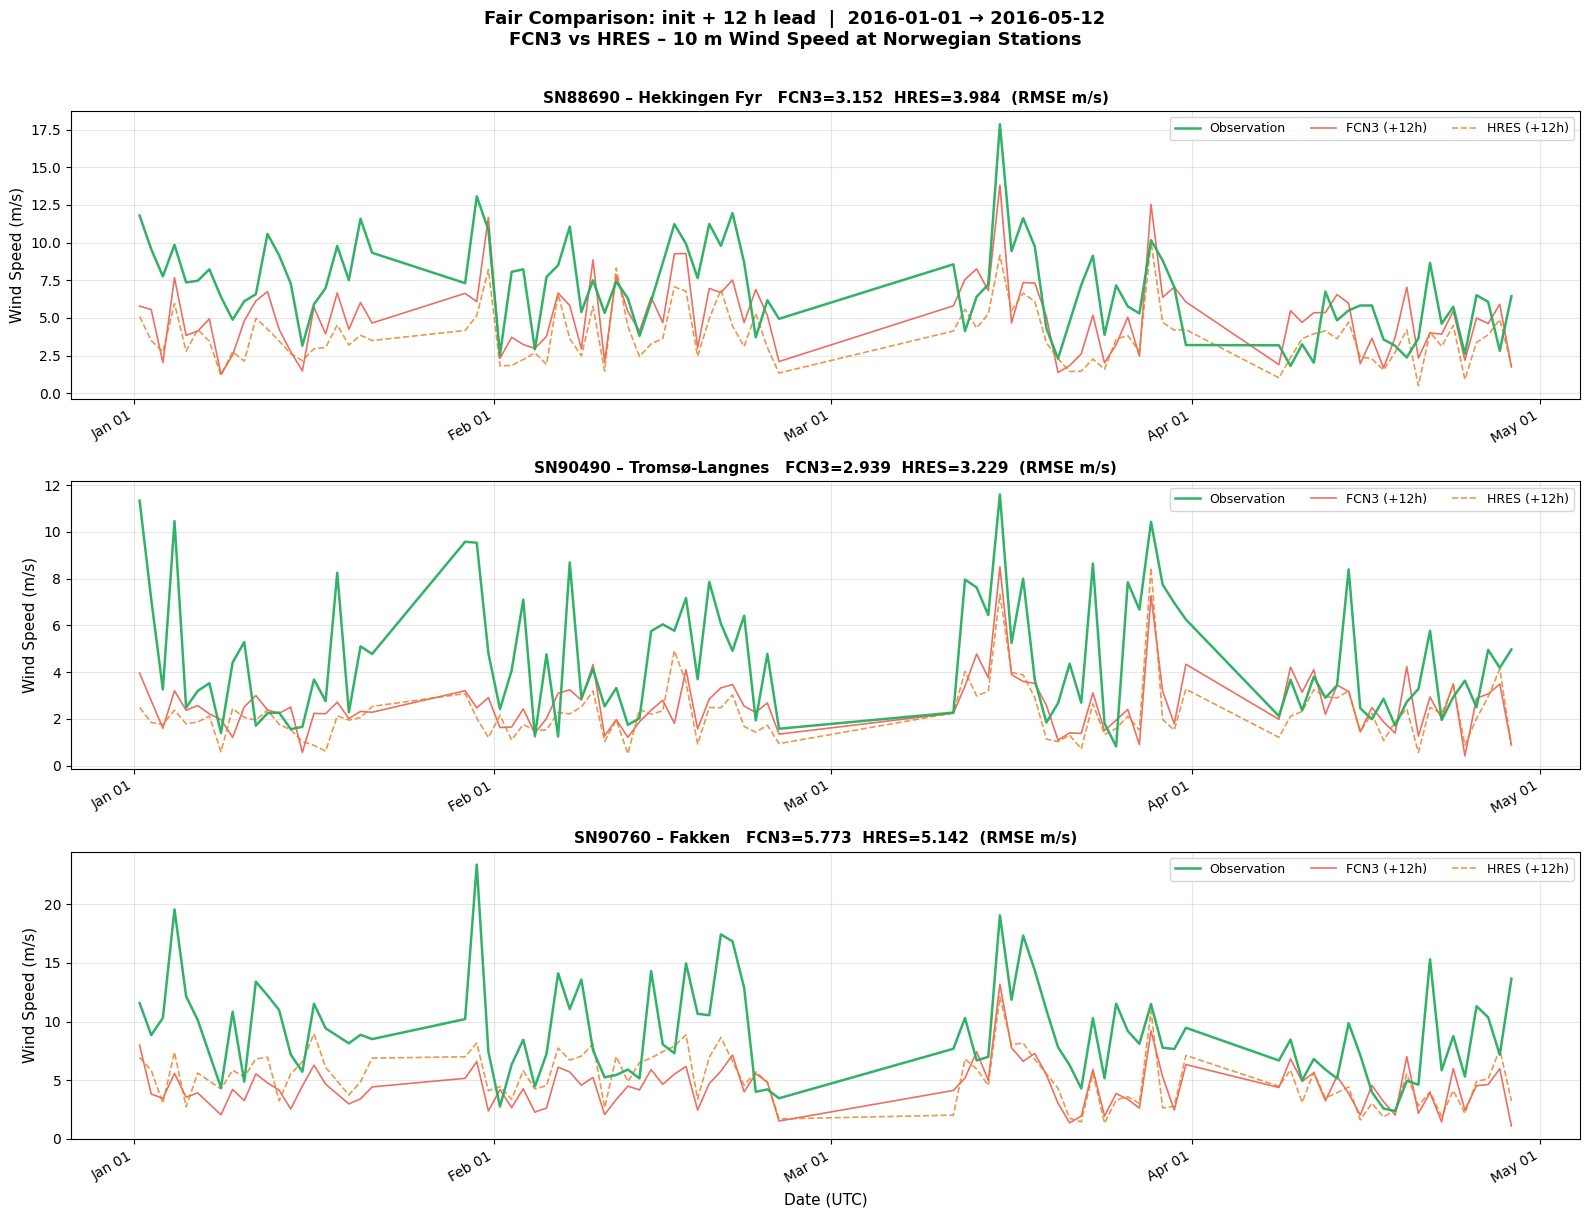

Saved: /cluster/home/siyan/github/WF-experiments/experiments/notebooks/figures/fcn3_hres_2016/comparison_time_series.png


In [78]:
_n   = len(STATIONS)
fig, axes = plt.subplots(_n, 1, figsize=(16, 4 * _n))
if _n == 1:
    axes = [axes]

for ax, (sid, info) in zip(axes, STATIONS.items()):
    sub = merged[merged['station'] == sid].sort_values('valid_time')
    ax.plot(sub['valid_time'], sub['obs_wind'],
            color=CLR['Obs'],  lw=1.8, label='Observation', alpha=0.95, zorder=4)
    ax.plot(sub['valid_time'], sub['fcn3_wind'],
            color=CLR['FCN3'], lw=1.2, label=f'FCN3 (+{LEAD_H}h)', alpha=0.80, zorder=2)
    ax.plot(sub['valid_time'], sub['hres_wind'],
            color=CLR['HRES'], lw=1.2, label=f'HRES (+{LEAD_H}h)', alpha=0.80, zorder=3, linestyle='--')

    rf = metrics.loc[sid, 'FCN3 RMSE']
    rh = metrics.loc[sid, 'HRES RMSE']
    ax.set_title(
        f'{sid} – {info["name"]}   FCN3={rf:.3f}  HRES={rh:.3f}  (RMSE m/s)',
        fontsize=11, fontweight='bold'
    )
    ax.set_ylabel('Wind Speed (m/s)', fontsize=11)
    ax.legend(loc='upper right', fontsize=9, ncol=4)
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

axes[-1].set_xlabel('Date (UTC)', fontsize=11)
fig.suptitle(
    f'Fair Comparison: init + {LEAD_H} h lead  |  {PERIOD_START} → {PERIOD_END}\n'
    'FCN3 vs HRES – 10 m Wind Speed at Norwegian Stations',
    fontsize=13, fontweight='bold', y=1.01
)
plt.tight_layout()
out = FIG_DIR / 'comparison_time_series.png'
plt.savefig(out, dpi=130, bbox_inches='tight')
plt.show()
print(f'Saved: {out}')


## 7  Error Bar Charts

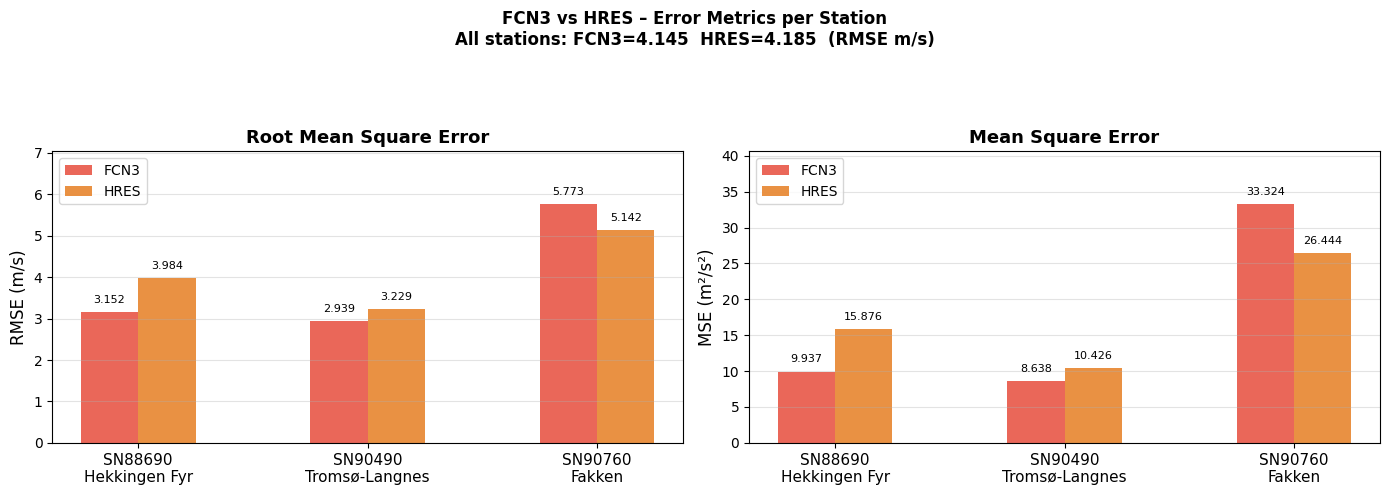

Saved: /cluster/home/siyan/github/WF-experiments/experiments/notebooks/figures/fcn3_hres_2016/comparison_metrics_bar.png


In [79]:
sids   = list(STATIONS.keys())
labels = [f'{s}\n{STATIONS[s]["name"]}' for s in sids]
mdf    = metrics.loc[sids]
x, w   = np.arange(len(sids)), 0.25

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (metric, ylabel, title) in zip(
    axes,
    [('RMSE', 'RMSE (m/s)',   'Root Mean Square Error'),
     ('MSE',  'MSE (m²/s²)', 'Mean Square Error')],
):
    b1 = ax.bar(x - w/2, mdf[f'FCN3 {metric}'], w, label='FCN3', color=CLR['FCN3'], alpha=0.85)
    b2 = ax.bar(x + w/2, mdf[f'HRES {metric}'], w, label='HRES', color=CLR['HRES'], alpha=0.85)
    all_bars = [*b1, *b2]

    ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=11)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.legend(fontsize=10); ax.grid(axis='y', alpha=0.35)
    max_h = max(b.get_height() for b in all_bars)
    for b in all_bars:
        ax.text(b.get_x() + b.get_width() / 2, b.get_height() + max_h * 0.03,
                f'{b.get_height():.3f}', ha='center', va='bottom', fontsize=8)
    ax.set_ylim(0, max_h * 1.22)

ov = metrics.loc['All Stations']
fig.suptitle(
    f'FCN3 vs HRES – Error Metrics per Station\n'
    f'All stations: FCN3={ov["FCN3 RMSE"]:.3f}  HRES={ov["HRES RMSE"]:.3f}  (RMSE m/s)',
    fontsize=12, fontweight='bold'
)
plt.tight_layout(rect=[0, 0, 1, 0.88])
out = FIG_DIR / 'comparison_metrics_bar.png'
plt.savefig(out, dpi=130, bbox_inches='tight')
plt.show()
print(f'Saved: {out}')


## 8  Scatter Plots (Obs vs Predicted)

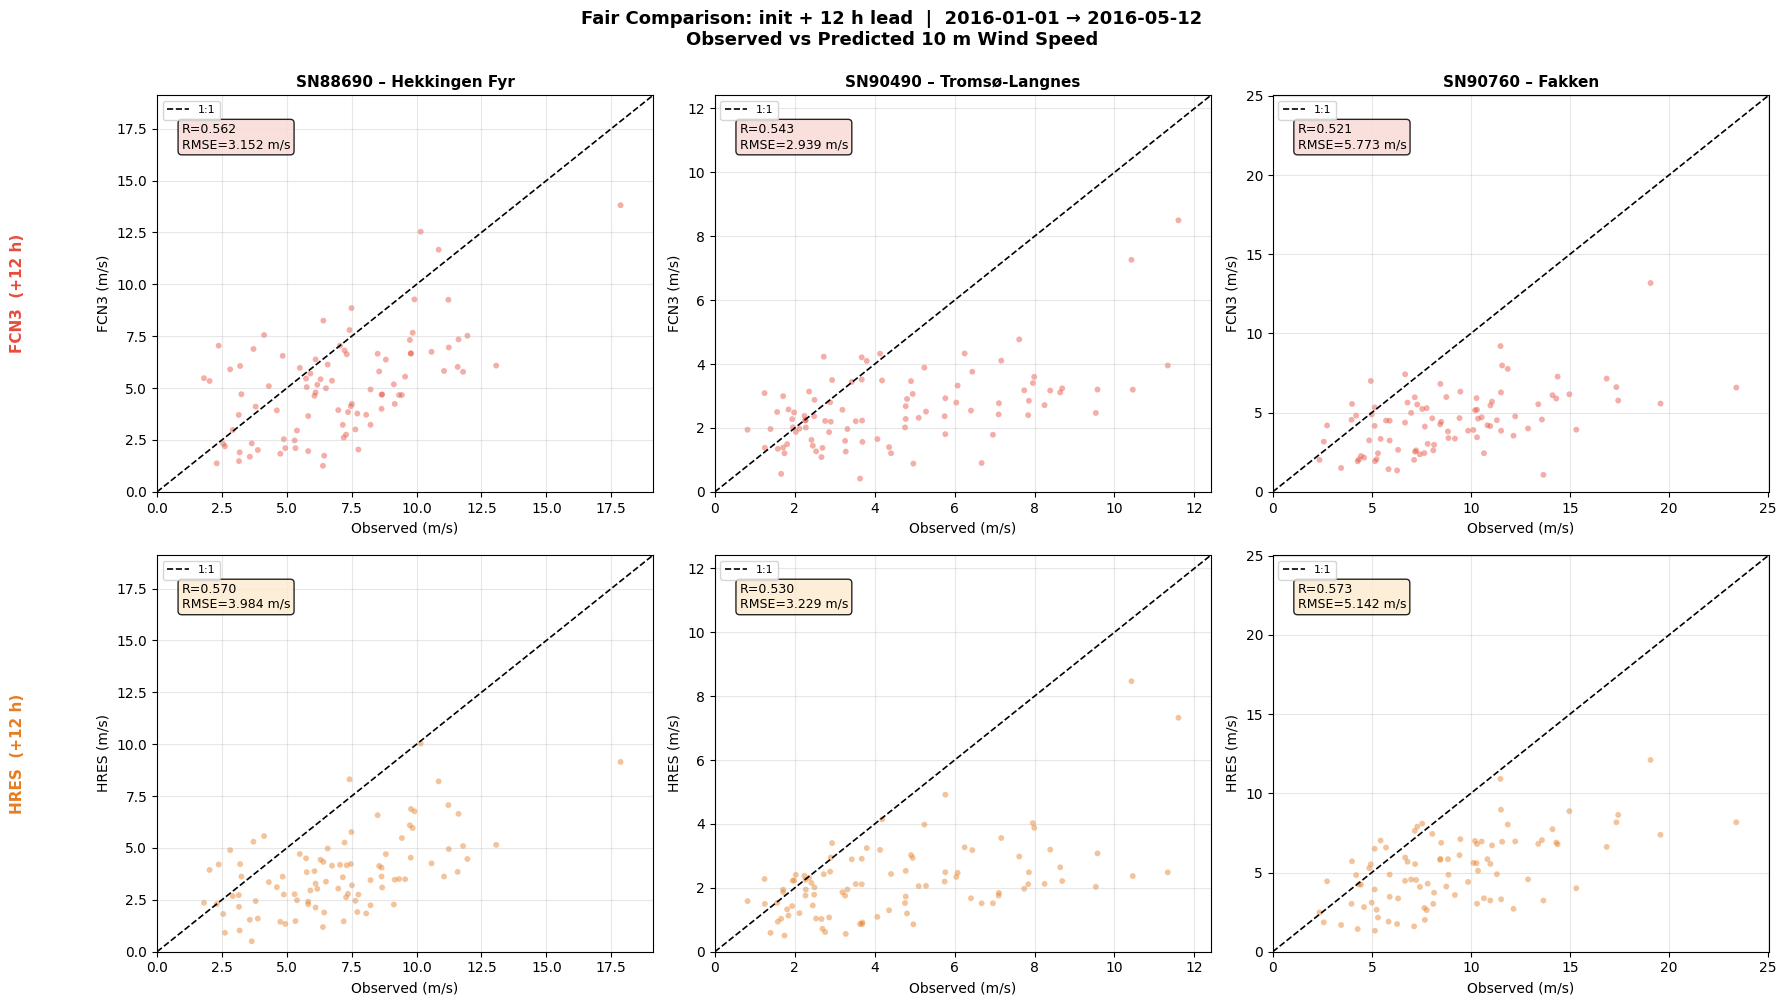

Saved: /cluster/home/siyan/github/WF-experiments/experiments/notebooks/figures/fcn3_hres_2016/comparison_scatter.png


In [ ]:
_n   = len(STATIONS)
fig, axes = plt.subplots(2, _n, figsize=(5 * _n + 3, 10), squeeze=False)

model_rows = [
    ('fcn3_wind', 'FCN3', 'FCN3 RMSE', CLR['FCN3'], '#FADBD8'),
    ('hres_wind', 'HRES', 'HRES RMSE', CLR['HRES'], '#FDEBD0'),
]

for col, (sid, info) in enumerate(STATIONS.items()):
    sub  = merged[merged['station'] == sid]
    vmax = max(sub['obs_wind'].max(), sub['fcn3_wind'].max(), sub['hres_wind'].max()) * 1.07

    for row_i, (wind_col, label, rmse_key, clr, fc) in enumerate(model_rows):
        ax = axes[row_i, col]
        ax.scatter(sub['obs_wind'], sub[wind_col], alpha=0.45, s=18, color=clr, edgecolors='none')
        ax.plot([0, vmax], [0, vmax], 'k--', lw=1.2, label='1:1')
        ax.set_xlim(0, vmax); ax.set_ylim(0, vmax)
        ax.set_xlabel('Observed (m/s)', fontsize=10)
        ax.set_ylabel(f'{label} (m/s)', fontsize=10)
        if row_i == 0:
            ax.set_title(f'{sid} – {info["name"]}', fontsize=11, fontweight='bold')
        r = np.corrcoef(sub['obs_wind'], sub[wind_col])[0, 1]
        ax.text(0.05, 0.93, f'R={r:.3f}\nRMSE={metrics.loc[sid, rmse_key]:.3f} m/s',
                transform=ax.transAxes, fontsize=9, va='top',
                bbox=dict(boxstyle='round', facecolor=fc, alpha=0.85))
        ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.tight_layout(rect=[0.05, 0, 1, 0.95])
for row_axes, label, clr in [
    (axes[0], f'FCN3  (+{LEAD_H} h)', CLR['FCN3']),
    (axes[1], f'HRES  (+{LEAD_H} h)', CLR['HRES']),
]:
    bbox  = row_axes[0].get_position()
    y_mid = (bbox.y0 + bbox.y1) / 2
    fig.text(0.01, y_mid, label, va='center', rotation='vertical',
             fontsize=11, fontweight='bold', color=clr)

fig.suptitle(
    f'Fair Comparison: init + {LEAD_H} h lead  |  {PERIOD_START} → {PERIOD_END}\n'
    'Observed vs Predicted 10 m Wind Speed',
    fontsize=13, fontweight='bold', y=1.00
)
out = FIG_DIR / 'comparison_scatter.png'
plt.savefig(out, dpi=130, bbox_inches='tight')
plt.show()
print(f'Saved: {out}')


## 9  Accuracy Scatter (+/-2 m/s Tolerance Band)

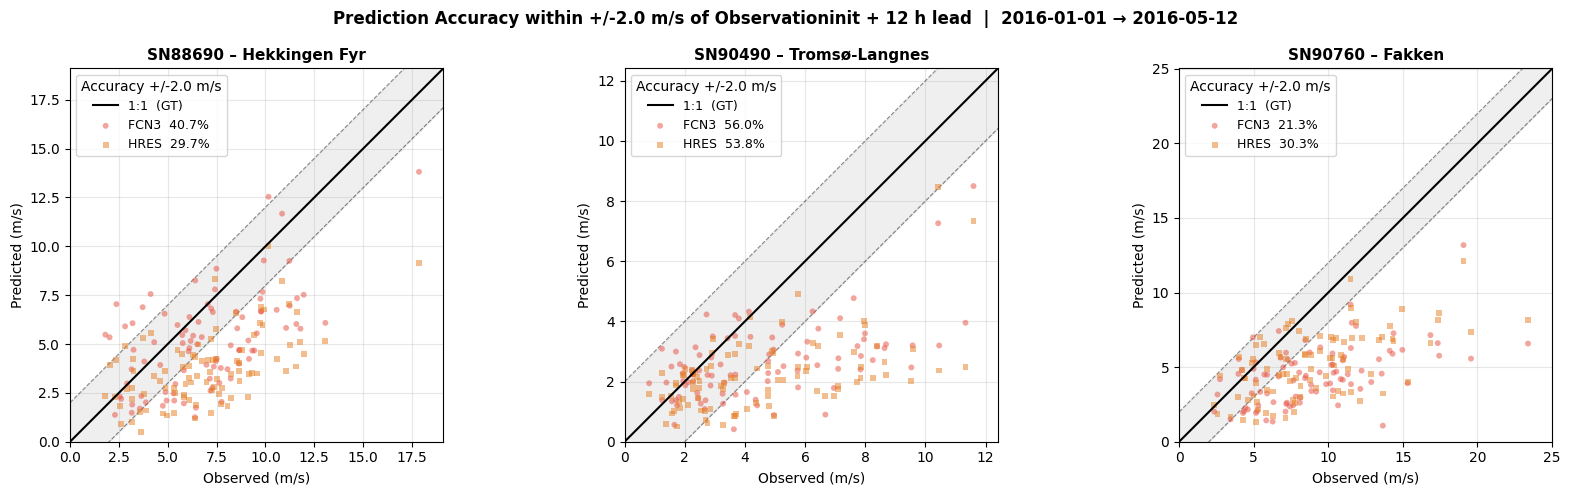

Saved: /cluster/home/siyan/github/WF-experiments/experiments/notebooks/figures/fcn3_hres_2016/comparison_accuracy_scatter.png


In [81]:
TOLERANCE = 2.0  # m/s — predictions within this band count as accurate

_n   = len(STATIONS)
fig, axes = plt.subplots(1, _n, figsize=(5 * _n + 2, 5), squeeze=False)
axes = axes[0]

for col, (sid, info) in enumerate(STATIONS.items()):
    ax   = axes[col]
    sub  = merged[merged['station'] == sid]
    vmax = max(sub['obs_wind'].max(), sub['fcn3_wind'].max(),
               sub['hres_wind'].max()) * 1.07
    x    = np.linspace(0, vmax, 200)

    # 1:1 line + tolerance band
    ax.fill_between(x, x - TOLERANCE, x + TOLERANCE,
                    alpha=0.12, color='gray', zorder=1)
    ax.plot(x, x + TOLERANCE, 'k--', lw=0.8, alpha=0.45, zorder=2)
    ax.plot(x, x - TOLERANCE, 'k--', lw=0.8, alpha=0.45, zorder=2)
    ax.plot(x, x, 'k-',  lw=1.5, label='1:1  (GT)', zorder=5)

    # Models
    plot_models = [
        ('fcn3_wind', 'FCN3', CLR['FCN3'], 'o'),
        ('hres_wind', 'HRES', CLR['HRES'], 's'),
    ]
    for wind_col, label, clr, marker in plot_models:
        s2 = sub.dropna(subset=[wind_col])
        obs_v  = s2['obs_wind'].values
        pred_v = s2[wind_col].values
        acc    = 100.0 * (np.abs(pred_v - obs_v) <= TOLERANCE).mean()
        ax.scatter(obs_v, pred_v, alpha=0.50, s=18, color=clr, marker=marker,
                   edgecolors='none', zorder=3,
                   label=f'{label}  {acc:.1f}%')

    ax.set_xlim(0, vmax); ax.set_ylim(0, vmax)
    ax.set_aspect('equal', adjustable='box')
    ax.set_xlabel('Observed (m/s)', fontsize=10)
    ax.set_ylabel('Predicted (m/s)', fontsize=10)
    ax.set_title(f'{sid} – {info["name"]}', fontsize=11, fontweight='bold')
    ax.legend(fontsize=9, loc='upper left', title=f'Accuracy +/-{TOLERANCE} m/s')
    ax.grid(alpha=0.3)

fig.suptitle(
    f'Prediction Accuracy within +/-{TOLERANCE} m/s of Observation'
    f'init + {LEAD_H} h lead  |  {PERIOD_START} → {PERIOD_END}',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
out = FIG_DIR / 'comparison_accuracy_scatter.png'
plt.savefig(out, dpi=130, bbox_inches='tight')
plt.show()
print(f'Saved: {out}')


## 10  Summary Table

In [83]:
summary = metrics.copy()
summary['ΔRMSE HRES−FCN3'] = summary['HRES RMSE'] - summary['FCN3 RMSE']

print(f'Final Summary  |  lead = +{LEAD_H} h  |  {PERIOD_START} → {PERIOD_END}')
print('=' * 110)
print(summary.round(4).to_string())




Final Summary  |  lead = +12 h  |  2016-01-01 → 2016-05-12
                N  FCN3 RMSE  HRES RMSE  FCN3 MSE  HRES MSE  FCN3 Bias  HRES Bias  ΔRMSE HRES−FCN3
Station                                                                                           
SN88690        91     3.1524     3.9845    9.9373   15.8762    -1.8634    -3.1701           0.8321
SN90490        91     2.9390     3.2290    8.6380   10.4262    -1.9428    -2.3413           0.2899
SN90760        89     5.7727     5.1424   33.3237   26.4441    -4.5827    -3.8854          -0.6303
All Stations  271     4.1450     4.1853   17.1814   17.5168    -2.7831    -3.1267           0.0403
